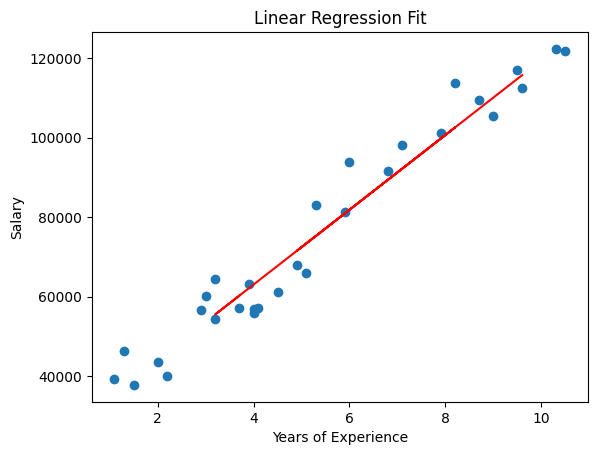

R2 Score: 0.9024461774180497
[72440.65962693]


C:\Users\digit\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib
df = pd.read_csv("../data/salary_data.csv")
#plt.scatter(df["YearsExperience"], df["Salary"])
#plt.xlabel("Year Of Experience")
#plt.ylabel("Salary")
#plt.title("Experience vs Salary")
#plt.show()
X = df[["YearsExperience"]]   # independent feature
y = df["Salary"] 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#print(X_train.shape)
#print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    "Actual Salary": y_test,
    "Predicted Salary": y_pred
})

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

plt.scatter(X, y)
plt.plot(X_test, y_pred, color="red")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Linear Regression Fit")


plt.show()
print("R2 Score:", r2)
joblib.dump(model, "../models/linear_regression.pkl")

loaded_model = joblib.load("../models/linear_regression.pkl")
prediction = loaded_model.predict([[5]])
print(prediction)